In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision import models, datasets
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import time
from pathlib import Path
from tqdm import tqdm

# ─── Reproducibilidad ─────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ─── Rutas ────────────────────────────────────────────
PROJECT_ROOT  = Path("C:/Projects/raptor_australia")
PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed"
MODELS_DIR    = PROJECT_ROOT / "models"
RESULTS_DIR   = PROJECT_ROOT / "results"
METADATA_DIR  = PROJECT_ROOT / "dataset" / "metadata"
MODELS_DIR.mkdir(exist_ok=True)

# ─── Hiperparámetros ──────────────────────────────────
IMG_SIZE     = 380
NUM_CLASSES  = 8
BATCH_SIZE   = 8      # Ajustado para RTX 3050 (4GB VRAM)
NUM_EPOCHS_P1 = 10    # Fase 1: solo clasificador
NUM_EPOCHS_P2 = 30    # Fase 2: fine-tuning
LR_PHASE1    = 1e-3
LR_PHASE2    = 1e-4
DROPOUT      = 0.4

# ─── Dispositivo ──────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Dispositivo: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ─── Mapeo de clases ──────────────────────────────────
CLASS_NAMES = {
    0: "Wedge-tailed Eagle",
    1: "Peregrine Falcon",
    2: "Spotted Harrier",
    3: "Brown Goshawk",
    4: "Nankeen Kestrel",
    5: "Black-shouldered Kite",
    6: "Square-tailed Kite",
    7: "Little Eagle"
}

CLASS_KEYS = {
    0: "aquila_audax",
    1: "falco_peregrinus",
    2: "circus_assimilis",
    3: "tachyspiza_fasciata",
    4: "falco_cenchroides",
    5: "elanus_axillaris",
    6: "lophoictinia_isura",
    7: "hieraaetus_morphnoides"
}

print(f"\n📋 Clases del modelo:")
for i, name in CLASS_NAMES.items():
    print(f"   Clase {i}: {name}")

✅ Dispositivo: cuda
   GPU: NVIDIA GeForce RTX 3050 Laptop GPU
   VRAM: 4.0 GB

📋 Clases del modelo:
   Clase 0: Wedge-tailed Eagle
   Clase 1: Peregrine Falcon
   Clase 2: Spotted Harrier
   Clase 3: Brown Goshawk
   Clase 4: Nankeen Kestrel
   Clase 5: Black-shouldered Kite
   Clase 6: Square-tailed Kite
   Clase 7: Little Eagle


In [26]:
# Estadísticas de normalización de ImageNet
# EfficientNetB4 fue pre-entrenado con estos valores
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ─── Transformaciones para ENTRENAMIENTO ──────────────
# Incluye Data Augmentation para que el modelo
# aprenda a reconocer aves en diferentes condiciones
train_transform = transforms.Compose([
    transforms.Resize((420, 420)),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.7, 1.0)   # Simula diferentes distancias al ave
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.1
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ─── Transformaciones para VALIDACIÓN y PRUEBA ────────
# Sin augmentation — evaluamos el modelo real
eval_transform = transforms.Compose([
    transforms.Resize((420, 420)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("✅ Transformaciones definidas")
print(f"\n   Train: Resize → RandomCrop → Flip → Rotate")
print(f"          → ColorJitter → Blur → Normalize")
print(f"   Val/Test: Resize → CenterCrop → Normalize")

✅ Transformaciones definidas

   Train: Resize → RandomCrop → Flip → Rotate
          → ColorJitter → Blur → Normalize
   Val/Test: Resize → CenterCrop → Normalize


In [27]:
# ─── Cargar datasets desde carpetas ───────────────────
# ImageFolder detecta automáticamente las clases
# a partir de los nombres de las subcarpetas

train_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "test"),
    transform=eval_transform
)

print("✅ Datasets cargados")
print(f"   Train: {len(train_dataset):>5} imágenes")
print(f"   Val:   {len(val_dataset):>5} imágenes")
print(f"   Test:  {len(test_dataset):>5} imágenes")
print(f"\n   Clases detectadas: {train_dataset.classes}")

# ─── Verificar que el orden de clases es correcto ─────
print(f"\n   Índice → Carpeta:")
for idx, clase in enumerate(train_dataset.classes):
    print(f"   {idx} → {clase}")

✅ Datasets cargados
   Train:  2110 imágenes
   Val:     335 imágenes
   Test:    361 imágenes

   Clases detectadas: ['aquila_audax', 'circus_assimilis', 'elanus_axillaris', 'falco_cenchroides', 'falco_peregrinus', 'hieraaetus_morphnoides', 'lophoictinia_isura', 'tachyspiza_fasciata']

   Índice → Carpeta:
   0 → aquila_audax
   1 → circus_assimilis
   2 → elanus_axillaris
   3 → falco_cenchroides
   4 → falco_peregrinus
   5 → hieraaetus_morphnoides
   6 → lophoictinia_isura
   7 → tachyspiza_fasciata


In [28]:
from sklearn.utils.class_weight import compute_class_weight

# ─── Calcular pesos por clase ─────────────────────────
# Las clases con menos imágenes reciben más peso
# para compensar el desbalance

labels_train = [label for _, label in train_dataset.samples]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_train),
    y=labels_train
)

weights_tensor = torch.FloatTensor(class_weights).to(device)

print("⚖️  Pesos por clase calculados:")
for i, (name, weight) in enumerate(
    zip(train_dataset.classes, class_weights)
):
    print(f"   Clase {i} ({name:<25}) → peso: {weight:.3f}")

# ─── DataLoaders ──────────────────────────────────────
# num_workers=0 para Windows (evita errores de multiprocessing)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True    # Acelera transferencia CPU→GPU
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print(f"\n✅ DataLoaders creados")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Batches por época (train): {len(train_loader)}")

⚖️  Pesos por clase calculados:
   Clase 0 (aquila_audax             ) → peso: 1.104
   Clase 1 (circus_assimilis         ) → peso: 1.099
   Clase 2 (elanus_axillaris         ) → peso: 0.903
   Clase 3 (falco_cenchroides        ) → peso: 0.906
   Clase 4 (falco_peregrinus         ) → peso: 1.104
   Clase 5 (hieraaetus_morphnoides   ) → peso: 0.932
   Clase 6 (lophoictinia_isura       ) → peso: 0.919
   Clase 7 (tachyspiza_fasciata      ) → peso: 1.104

✅ DataLoaders creados
   Batch size: 8
   Batches por época (train): 264


In [29]:
class AustralianRaptorCNN(nn.Module):
    """
    Modelo CNN para identificación de aves rapaces
    australianas post-incendio Black Summer.

    Base: EfficientNet-B4 pre-entrenado en ImageNet
    Clases: 8 especies de rapaces australianas
    """

    def __init__(self, num_classes=NUM_CLASSES,
                 dropout_rate=DROPOUT):
        super(AustralianRaptorCNN, self).__init__()

        # Cargar EfficientNet-B4 con pesos de ImageNet
        self.backbone = models.efficientnet_b4(
            weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
        )

        # Número de características de la capa final original
        num_features = (self.backbone
                        .classifier[1].in_features)

        # Reemplazar clasificador original (1000 clases ImageNet)
        # por uno nuevo de 8 clases (nuestras rapaces)
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def freeze_backbone(self):
        """Congela todas las capas del backbone."""
        for param in self.backbone.features.parameters():
            param.requires_grad = False
        print("🔒 Backbone congelado")

    def unfreeze_last_blocks(self, num_blocks=3):
        """Descongela los últimos N bloques para fine-tuning."""
        blocks = list(self.backbone.features.children())
        for block in blocks[-num_blocks:]:
            for param in block.parameters():
                param.requires_grad = True
        total = sum(p.numel() for p in self.parameters()
                    if p.requires_grad)
        print(f"🔓 Últimos {num_blocks} bloques descongelados")
        print(f"   Parámetros entrenables: {total:,}")


# Crear modelo y moverlo a GPU
model = AustralianRaptorCNN(
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT
).to(device)

# Función de pérdida con pesos por clase
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Modelo creado")
print(f"   Total parámetros: {total_params:,}")
print(f"   Dispositivo:      {device}")

✅ Modelo creado
   Total parámetros: 18,470,736
   Dispositivo:      cuda


In [30]:
from sklearn.metrics import f1_score, accuracy_score

def train_epoch(model, loader, criterion, optimizer):
    """Ejecuta una época de entrenamiento."""
    model.train()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping — evita explosión de gradientes
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average="macro", zero_division=0)

    return avg_loss, acc, f1


def eval_epoch(model, loader, criterion):
    """Evalúa el modelo en validación o prueba."""
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds,
                        average="macro", zero_division=0)

    return avg_loss, acc, f1, all_preds, all_labels

print("✅ Funciones de entrenamiento definidas")

✅ Funciones de entrenamiento definidas


In [31]:
print("="*55)
print("  FASE 1 — FEATURE EXTRACTION")
print("  Solo se entrena el clasificador")
print("="*55)

# Congelar backbone — solo entrena el clasificador nuevo
model.freeze_backbone()

optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
    weight_decay=1e-4
)

scheduler_p1 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1,
    T_max=NUM_EPOCHS_P1,
    eta_min=1e-5
)

# ─── Historial de entrenamiento ───────────────────────
history = {
    "phase":       [],
    "epoch":       [],
    "train_loss":  [],
    "train_acc":   [],
    "train_f1":    [],
    "val_loss":    [],
    "val_acc":     [],
    "val_f1":      []
}

best_val_f1   = 0.0
best_model_path = MODELS_DIR / "best_model.pth"

print(f"\n{'Época':>6} {'T.Loss':>8} {'T.Acc':>7} "
      f"{'T.F1':>7} {'V.Loss':>8} {'V.Acc':>7} "
      f"{'V.F1':>7} {'LR':>10}")
print("-" * 68)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS_P1 + 1):

    # Entrenamiento
    t_loss, t_acc, t_f1 = train_epoch(
        model, train_loader, criterion, optimizer_p1
    )

    # Validación
    v_loss, v_acc, v_f1, _, _ = eval_epoch(
        model, val_loader, criterion
    )

    scheduler_p1.step()
    current_lr = scheduler_p1.get_last_lr()[0]

    # Guardar historial
    history["phase"].append(1)
    history["epoch"].append(epoch)
    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["train_f1"].append(t_f1)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["val_f1"].append(v_f1)

    # Guardar mejor modelo
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        torch.save({
            "epoch":      epoch,
            "phase":      1,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer_p1.state_dict(),
            "val_f1":     v_f1,
            "val_acc":    v_acc,
            "class_names":CLASS_NAMES,
            "class_keys": CLASS_KEYS
        }, best_model_path)
        flag = " ⭐"
    else:
        flag = ""

    print(f"{epoch:>6} {t_loss:>8.4f} {t_acc:>7.3f} "
          f"{t_f1:>7.3f} {v_loss:>8.4f} {v_acc:>7.3f} "
          f"{v_f1:>7.3f} {current_lr:>10.2e}{flag}")

elapsed = time.time() - start_time
print(f"\n✅ Fase 1 completada en {elapsed/60:.1f} minutos")
print(f"   Mejor Val F1: {best_val_f1:.4f}")

  FASE 1 — FEATURE EXTRACTION
  Solo se entrena el clasificador
🔒 Backbone congelado

 Época   T.Loss   T.Acc    T.F1   V.Loss   V.Acc    V.F1         LR
--------------------------------------------------------------------
     1   1.7987   0.338   0.337   1.5307   0.415   0.372   9.76e-04 ⭐
     2   1.4970   0.472   0.469   1.3411   0.516   0.487   9.05e-04 ⭐
     3   1.4194   0.484   0.483   1.3484   0.496   0.482   7.96e-04
     4   1.3613   0.509   0.510   1.3018   0.531   0.522   6.58e-04 ⭐
     5   1.3153   0.516   0.514   1.3178   0.516   0.493   5.05e-04
     6   1.2622   0.545   0.545   1.2967   0.516   0.504   3.52e-04
     7   1.2558   0.539   0.537   1.2396   0.540   0.525   2.14e-04 ⭐
     8   1.2128   0.570   0.569   1.2090   0.558   0.540   1.05e-04 ⭐
     9   1.1721   0.575   0.574   1.2650   0.531   0.509   3.42e-05
    10   1.1854   0.590   0.591   1.2528   0.519   0.498   1.00e-05

✅ Fase 1 completada en 14.1 minutos
   Mejor Val F1: 0.5396


In [33]:
print("="*55)
print("  FASE 2 — FINE-TUNING")
print("  Se descongelan últimos 3 bloques")
print("="*55)

# Descongelar últimos 3 bloques del backbone
model.unfreeze_last_blocks(num_blocks=3)

# Cargar mejor modelo de Fase 1
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"\n📂 Modelo Fase 1 cargado (Val F1: "
      f"{checkpoint['val_f1']:.4f})")

# Optimizador con learning rates diferenciados
optimizer_p2 = optim.AdamW([
    {
        "params": model.backbone.features[-3:].parameters(),
        "lr": LR_PHASE2
    },
    {
        "params": model.backbone.classifier.parameters(),
        "lr": LR_PHASE2 * 5
    }
], weight_decay=1e-4)

scheduler_p2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# Early stopping
patience        = 10
epochs_no_improve = 0

print(f"\n{'Época':>6} {'T.Loss':>8} {'T.Acc':>7} "
      f"{'T.F1':>7} {'V.Loss':>8} {'V.Acc':>7} "
      f"{'V.F1':>7} {'':>5}")
print("-" * 65)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS_P2 + 1):

    t_loss, t_acc, t_f1 = train_epoch(
        model, train_loader, criterion, optimizer_p2
    )
    v_loss, v_acc, v_f1, _, _ = eval_epoch(
        model, val_loader, criterion
    )

    scheduler_p2.step(v_f1)

    history["phase"].append(2)
    history["epoch"].append(NUM_EPOCHS_P1 + epoch)
    history["train_loss"].append(t_loss)
    history["train_acc"].append(t_acc)
    history["train_f1"].append(t_f1)
    history["val_loss"].append(v_loss)
    history["val_acc"].append(v_acc)
    history["val_f1"].append(v_f1)

    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        epochs_no_improve = 0
        torch.save({
            "epoch":      NUM_EPOCHS_P1 + epoch,
            "phase":      2,
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer_p2.state_dict(),
            "val_f1":     v_f1,
            "val_acc":    v_acc,
            "class_names":CLASS_NAMES,
            "class_keys": CLASS_KEYS
        }, best_model_path)
        flag = " ⭐"
    else:
        epochs_no_improve += 1
        flag = ""

    print(f"{NUM_EPOCHS_P1+epoch:>6} {t_loss:>8.4f} "
          f"{t_acc:>7.3f} {t_f1:>7.3f} {v_loss:>8.4f} "
          f"{v_acc:>7.3f} {v_f1:>7.3f}{flag}")

    # Early stopping
    if epochs_no_improve >= patience:
        print(f"\n⏹️  Early stopping en época "
              f"{NUM_EPOCHS_P1 + epoch}")
        break

elapsed = time.time() - start_time
print(f"\n✅ Fase 2 completada en {elapsed/60:.1f} minutos")
print(f"   Mejor Val F1 global: {best_val_f1:.4f}")

  FASE 2 — FINE-TUNING
  Se descongelan últimos 3 bloques
🔓 Últimos 3 bloques descongelados
   Parámetros entrenables: 14,834,752

📂 Modelo Fase 1 cargado (Val F1: 0.6177)

 Época   T.Loss   T.Acc    T.F1   V.Loss   V.Acc    V.F1      
-----------------------------------------------------------------
    11   0.7477   0.747   0.747   0.9677   0.648   0.623 ⭐
    12   0.6889   0.760   0.762   0.8654   0.672   0.645 ⭐
    13   0.6770   0.760   0.759   0.8772   0.681   0.653 ⭐
    14   0.6540   0.776   0.777   0.9798   0.660   0.643
    15   0.6064   0.791   0.792   0.8481   0.719   0.690 ⭐
    16   0.5983   0.791   0.791   0.8596   0.690   0.667
    17   0.5350   0.815   0.814   0.7949   0.725   0.686
    18   0.5229   0.820   0.820   0.8421   0.737   0.705 ⭐
    19   0.5046   0.828   0.828   0.8937   0.707   0.677
    20   0.4617   0.840   0.840   0.8620   0.737   0.709 ⭐
    21   0.4396   0.851   0.851   0.8959   0.728   0.695
    22   0.4498   0.845   0.845   0.9382   0.728   0.704
  

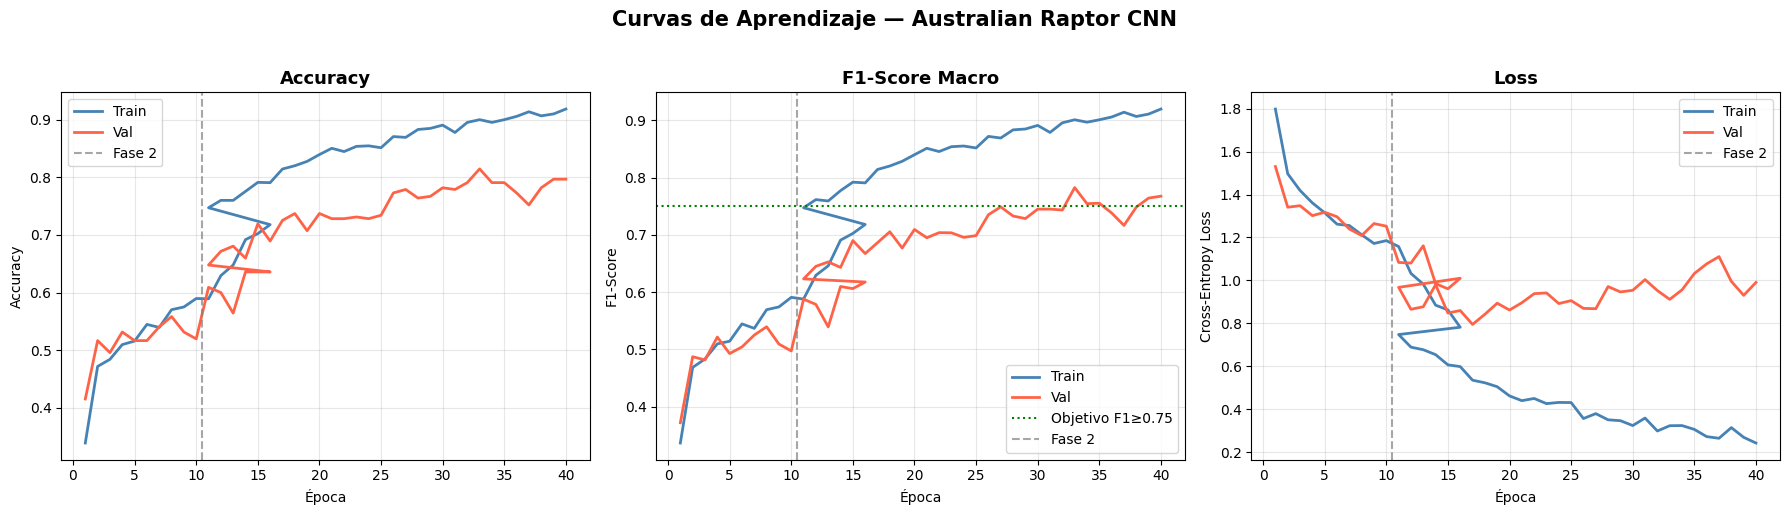

✅ Curvas guardadas en results/learning_curves.png


In [34]:
# Guardar historial completo
history_df = pd.DataFrame(history)
history_df.to_csv(
    RESULTS_DIR / "training_history.csv",
    index=False
)

# ─── Gráfica de curvas de aprendizaje ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_list = history_df["epoch"].tolist()

# Línea vertical que separa Fase 1 y Fase 2
phase2_start = NUM_EPOCHS_P1 + 0.5

# Accuracy
axes[0].plot(epochs_list, history_df["train_acc"],
             label="Train", color="steelblue", linewidth=2)
axes[0].plot(epochs_list, history_df["val_acc"],
             label="Val", color="tomato", linewidth=2)
axes[0].axvline(x=phase2_start, color="gray",
                linestyle="--", alpha=0.7, label="Fase 2")
axes[0].set_title("Accuracy", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1-Score
axes[1].plot(epochs_list, history_df["train_f1"],
             label="Train", color="steelblue", linewidth=2)
axes[1].plot(epochs_list, history_df["val_f1"],
             label="Val", color="tomato", linewidth=2)
axes[1].axhline(y=0.75, color="green", linestyle=":",
                linewidth=1.5, label="Objetivo F1≥0.75")
axes[1].axvline(x=phase2_start, color="gray",
                linestyle="--", alpha=0.7, label="Fase 2")
axes[1].set_title("F1-Score Macro", fontsize=13,
                  fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1-Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

# Loss
axes[2].plot(epochs_list, history_df["train_loss"],
             label="Train", color="steelblue", linewidth=2)
axes[2].plot(epochs_list, history_df["val_loss"],
             label="Val", color="tomato", linewidth=2)
axes[2].axvline(x=phase2_start, color="gray",
                linestyle="--", alpha=0.7, label="Fase 2")
axes[2].set_title("Loss", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("Cross-Entropy Loss")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(
    "Curvas de Aprendizaje — Australian Raptor CNN",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    str(RESULTS_DIR / "learning_curves.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Curvas guardadas en results/learning_curves.png")